## Setup

In [50]:
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


In [51]:
import os
import shutil

base_dir = "assignment_02_output"
subdirs = [
    "data/raw",
    "data/processed",
    "figures",
    "src"
]

for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")

raw_dir = os.path.join(base_dir, "data", "raw")
src_dir = os.path.join(os.getcwd(), "raw_data")

Created directory: assignment_02_output/data/raw
Created directory: assignment_02_output/data/processed
Created directory: assignment_02_output/figures
Created directory: assignment_02_output/src


In [52]:
import os

base_dir = "assignment_02_output"
raw_dir = os.path.join(base_dir, "data", "raw")

for fname in ["Diffraction SI_Au_Calib.dm4", "Si-SiGe.dm4"]:
    fpath = os.path.join(raw_dir, fname)
    print(fname, "FOUND" if os.path.exists(fpath) else "MISSING", "->", os.path.abspath(fpath))

Diffraction SI_Au_Calib.dm4 FOUND -> /Users/kylexu/Desktop/matsci465_project/HW2/assignment_02_output/data/raw/Diffraction SI_Au_Calib.dm4
Si-SiGe.dm4 FOUND -> /Users/kylexu/Desktop/matsci465_project/HW2/assignment_02_output/data/raw/Si-SiGe.dm4


## Task 1: Distinguish Navigation vs. Signal Axes

**Navigation axes** describe *where* the measurement is made (the real-space scan grid, e.g., scan_x and scan_y).

**Signal axes** describe *what* is measured at each scan position (for 4D-STEM, a 2D diffraction pattern in reciprocal space, e.g., k_x and k_y).

We verify the dataset has 2 navigation axes and 2 signal axes using the axes manager.

In [53]:
import os
import hyperspy.api as hs

dm4_path = os.path.join("assignment_02_output", "data", "raw", "Si-SiGe.dm4")

s4d = hs.load(dm4_path)
if isinstance(s4d, list):  
    s4d = s4d[0]

print("Loaded s4d:", type(s4d), "data.shape =", s4d.data.shape)
print("Axes:", [ax.name for ax in list(s4d.axes_manager.navigation_axes) + list(s4d.axes_manager.signal_axes)])

Loaded s4d: <class 'hyperspy._signals.signal2d.Signal2D'> data.shape = (480, 448, 77, 17)
Axes: ['z', <undefined>, 'x', 'y']


In [54]:
am = s4d.axes_manager

# We want: (scan_y, scan_x, k_y, k_x) = (77, 17, 480, 448)
# nav axes should be the last two dims (77,17), signal axes the first two (480,448)

# Set which dims are navigation vs signal
s4d = s4d.transpose(navigation_axes=(2, 3), signal_axes=(0, 1))

# Rename axes
am = s4d.axes_manager
am.navigation_axes[0].name = "scan_y"
am.navigation_axes[1].name = "scan_x"
am.signal_axes[0].name = "k_y"
am.signal_axes[1].name = "k_x"

print("After renaming:")
print("data.shape =", s4d.data.shape)
print("Axes:", [ax.name for ax in list(am.navigation_axes) + list(am.signal_axes)])

After renaming:
data.shape = (77, 17, 480, 448)
Axes: ['scan_y', 'scan_x', 'k_y', 'k_x']


In [55]:
def _axis_by_name(am, name):
    for ax in list(am.navigation_axes) + list(am.signal_axes):
        if ax.name == name:
            return ax
    raise ValueError(f"Axis '{name}' not found. Available: {[ax.name for ax in list(am.navigation_axes)+list(am.signal_axes)]}")

def enforce_order(s):
    """
    Goal for broadcasting:
      s.data.shape == (scan_y, scan_x, k_y, k_x)
    """
    am = s.axes_manager

    # Map axis name -> index in the underlying array
    axes_all = list(am.navigation_axes) + list(am.signal_axes)
    name2idx = {ax.name: ax.index_in_array for ax in axes_all}

    needed = ["scan_y", "scan_x", "k_y", "k_x"]
    missing = [n for n in needed if n not in name2idx]
    if missing:
        raise ValueError(f"Missing axis names {missing}. Current: {list(name2idx.keys())}")

    # Transpose into requested grouping/order
    nav = [name2idx["scan_y"], name2idx["scan_x"]]
    sig = [name2idx["k_y"], name2idx["k_x"]]
    s2 = s.transpose(navigation_axes=nav, signal_axes=sig)

    am2 = s2.axes_manager
    dshape = s2.data.shape

    # Verify by matching data dimensions to the named axis sizes
    assert dshape[0]  == _axis_by_name(am2, "scan_y").size
    assert dshape[1]  == _axis_by_name(am2, "scan_x").size
    assert dshape[-2] == _axis_by_name(am2, "k_y").size
    assert dshape[-1] == _axis_by_name(am2, "k_x").size

    print("PASS enforce_order")
    print(am2)
    print("data.shape =", dshape, " (expected: scan_y, scan_x, k_y, k_x)")
    return s2

s4d = enforce_order(s4d)

PASS enforce_order
<Axes manager, axes: (77, 17|480, 448)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
          scan_x |     77 |      0 |       0 |       2 |     nm 
          scan_y |     17 |      0 |       0 |       2 |     nm 
---------------- | ------ | ------ | ------- | ------- | ------ 
             k_x |    480 |      0 |       0 |   0.062 |   1/nm 
             k_y |    448 |      0 |       0 |   0.062 |   1/nm 
data.shape = (17, 77, 448, 480)  (expected: scan_y, scan_x, k_y, k_x)


In [56]:
from dataclasses import dataclass
import numpy as np

@dataclass
class VirtualDetector:
    kind: str                        # "BF", "ADF", or "custom"
    r_in: float = 0.0                # 1/nm (used for ADF)
    r_out: float = 0.0               # 1/nm (used for BF and ADF)
    center_px: tuple[int, int] | None = None   # (cy, cx) in diffraction pixels
    custom_mask: np.ndarray | None = None      # shape (k_y, k_x)

    def _get_k_axes(self, s4d):
        # We rely on axis names, not printed order
        am = s4d.axes_manager
        ky_ax = next(ax for ax in list(am.signal_axes) + list(am.navigation_axes) if ax.name == "k_y")
        kx_ax = next(ax for ax in list(am.signal_axes) + list(am.navigation_axes) if ax.name == "k_x")
        return ky_ax, kx_ax

    def _fov_rmax(self, s4d, cy, cx):
        ky_ax, kx_ax = self._get_k_axes(s4d)
        Ny, Nx = ky_ax.size, kx_ax.size
        dky, dkx = float(ky_ax.scale), float(kx_ax.scale)
        # max radius that still fits completely inside detector array
        return min(cy * dky, (Ny - 1 - cy) * dky, cx * dkx, (Nx - 1 - cx) * dkx)

    def check_within_fov(self, s4d):
        ky_ax, kx_ax = self._get_k_axes(s4d)
        Ny, Nx = ky_ax.size, kx_ax.size

        cy, cx = (Ny // 2, Nx // 2) if self.center_px is None else self.center_px
        if not (0 <= cy < Ny and 0 <= cx < Nx):
            raise ValueError(f"center_px {(cy,cx)} outside diffraction shape {(Ny,Nx)}")

        if self.kind == "custom":
            if self.custom_mask is None:
                raise ValueError("custom_mask is required for kind='custom'")
            if self.custom_mask.shape != (Ny, Nx):
                raise ValueError(f"custom_mask shape {self.custom_mask.shape} must be {(Ny,Nx)}")
            return

        if self.r_out <= 0:
            raise ValueError("r_out must be > 0 for BF/ADF")

        rmax = self._fov_rmax(s4d, cy, cx)
        if self.r_out > rmax + 1e-12:
            raise ValueError(f"r_out={self.r_out} exceeds FOV limit rmax={rmax:.6g} (1/nm)")

        if self.kind == "ADF":
            if self.r_in < 0 or self.r_in >= self.r_out:
                raise ValueError("ADF requires 0 <= r_in < r_out")

    def make_mask(self, s4d) -> np.ndarray:
        ky_ax, kx_ax = self._get_k_axes(s4d)
        Ny, Nx = ky_ax.size, kx_ax.size
        dky, dkx = float(ky_ax.scale), float(kx_ax.scale)

        cy, cx = (Ny // 2, Nx // 2) if self.center_px is None else self.center_px

        # Validate parameters first
        self.check_within_fov(s4d)

        if self.kind == "custom":
            return self.custom_mask.astype(float)

        ky = (np.arange(Ny) - cy) * dky
        kx = (np.arange(Nx) - cx) * dkx
        KY, KX = np.meshgrid(ky, kx, indexing="ij")
        R = np.sqrt(KY**2 + KX**2)

        if self.kind == "BF":
            return (R <= self.r_out).astype(float)

        if self.kind == "ADF":
            return ((R >= self.r_in) & (R <= self.r_out)).astype(float)

        raise ValueError(f"Unknown detector kind: {self.kind}")

# Quick sanity check
tmp = VirtualDetector(kind="BF", r_out=1.0)
ky_ax = next(ax for ax in list(s4d.axes_manager.signal_axes) + list(s4d.axes_manager.navigation_axes) if ax.name == "k_y")
kx_ax = next(ax for ax in list(s4d.axes_manager.signal_axes) + list(s4d.axes_manager.navigation_axes) if ax.name == "k_x")
Ny, Nx = ky_ax.size, kx_ax.size
cy, cx = Ny // 2, Nx // 2
rmax = tmp._fov_rmax(s4d, cy, cx)
print("Diffraction shape (k_y, k_x) =", (Ny, Nx))
print("Max detector radius rmax =", rmax, ky_ax.units)

Diffraction shape (k_y, k_x) = (448, 480)
Max detector radius rmax = 13.845037836581469 1/nm


In [57]:
import numpy as np
import hyperspy.api as hs

def apply_virtual_detector(s4d, det):
    """
    Assumes s4d.data.shape == (scan_y, scan_x, k_y, k_x).
    Returns a 2D virtual image (scan_y, scan_x) as a HyperSpy Signal2D,
    with correct x/y scan-axis labeling.
    """
    mask = det.make_mask(s4d)  # (k_y, k_x)
    img = (s4d.data * mask[None, None, :, :]).sum(axis=(-2, -1))  # (scan_y, scan_x)

    out = hs.signals.Signal2D(np.asarray(img))

    # Grab scan axes from the original signal (by name)
    axes_all = list(s4d.axes_manager.navigation_axes) + list(s4d.axes_manager.signal_axes)
    scan_y_ax = next(ax for ax in axes_all if ax.name == "scan_y")
    scan_x_ax = next(ax for ax in axes_all if ax.name == "scan_x")

    # HyperSpy: signal_axes[0] is x (horizontal), signal_axes[1] is y (vertical)
    out.axes_manager.signal_axes[0].name  = scan_x_ax.name
    out.axes_manager.signal_axes[0].scale = float(scan_x_ax.scale)
    out.axes_manager.signal_axes[0].units = scan_x_ax.units
    out.axes_manager.signal_axes[0].offset = float(getattr(scan_x_ax, "offset", 0.0))

    out.axes_manager.signal_axes[1].name  = scan_y_ax.name
    out.axes_manager.signal_axes[1].scale = float(scan_y_ax.scale)
    out.axes_manager.signal_axes[1].units = scan_y_ax.units
    out.axes_manager.signal_axes[1].offset = float(getattr(scan_y_ax, "offset", 0.0))

    return out

/Users/kylexu/miniconda3/envs/matsci465/lib/python3.10/site-packages/rsciio/utils/rgb_tools.py:62: VisibleDeprecationWarning: The module `rsciio.utils.rgb_tools` has been renamed to `rsciio.utils.rgb` and it will be removed in version 1.0.
  warnings.warn(


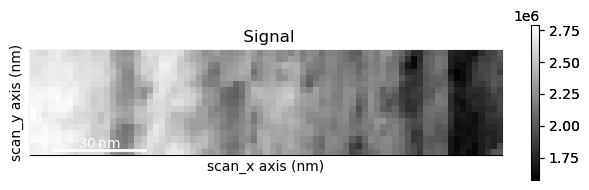

In [58]:
ky_ax = next(ax for ax in list(s4d.axes_manager.signal_axes) + list(s4d.axes_manager.navigation_axes) if ax.name == "k_y")
kx_ax = next(ax for ax in list(s4d.axes_manager.signal_axes) + list(s4d.axes_manager.navigation_axes) if ax.name == "k_x")

center_px = (ky_ax.size // 2, kx_ax.size // 2)  # (cy, cx) in diffraction pixels

bf = VirtualDetector(kind="BF", r_out=2.0, center_px=center_px)  # r_out in 1/nm

bf_img = apply_virtual_detector(s4d, bf)
bf_img.plot()

## Task 2: Load and Calibrate 4D-STEM Data

Use `py4DSTEM.io.read` to load a 4D-STEM dataset (e.g., `.dm4` or `.h5`).

**Note:** The dataset `Si-SiGe.dm4` should be available in the `raw_data` folder.

Set the scan step size (real space calibration) using `dataset.set_scan_step_size()`.

Perform Center of Mass (CoM) correction using `dataset.get_diffraction_shifts()` to center the unscattered beam.


In [59]:
import numpy as np

def _get_4d_data(obj):
    """Return 4D array with shape (scan_y, scan_x, k_y, k_x)."""
    data = getattr(obj, "data", obj)
    if data.ndim != 4:
        raise ValueError(f"Expected 4D data, got shape {data.shape}")
    return data

def _get_k_calibration(obj, ky_len, kx_len, origin="center"):
    """
    Try to read reciprocal calibration from HyperSpy axes_manager if present.
    Returns (ky, kx, unit_str). Defaults to 1/pixel if no metadata found.
    """
    unit = "px"
    dky = dkx = 1.0

    if hasattr(obj, "axes_manager"):
        axes_all = list(obj.axes_manager.navigation_axes) + list(obj.axes_manager.signal_axes)
        # find k_y / k_x axes by name if possible
        ax_ky = next((ax for ax in axes_all if getattr(ax, "name", "") in ["k_y", "ky"]), None)
        ax_kx = next((ax for ax in axes_all if getattr(ax, "name", "") in ["k_x", "kx"]), None)
        if ax_ky is not None:
            dky = float(getattr(ax_ky, "scale", 1.0))
            unit = getattr(ax_ky, "units", unit) or unit
        if ax_kx is not None:
            dkx = float(getattr(ax_kx, "scale", 1.0))
            unit = getattr(ax_kx, "units", unit) or unit

    if origin == "center":
        ky = (np.arange(ky_len) - (ky_len - 1) / 2.0) * dky
        kx = (np.arange(kx_len) - (kx_len - 1) / 2.0) * dkx
    else:  # "zero"
        ky = np.arange(ky_len) * dky
        kx = np.arange(kx_len) * dkx

    return ky, kx, unit

def total_intensity_map(obj):
    """Sum intensity over (k_y, k_x) at every scan position -> (scan_y, scan_x)."""
    I = _get_4d_data(obj)
    return np.asarray(I.sum(axis=(-2, -1)))

def com_maps(obj, origin="center", eps=1e-12, out_units="native"):
    """
    Center-of-mass maps in reciprocal space:
      com_y, com_x with shape (scan_y, scan_x)
    out_units:
      - "native": whatever the k-axes units are (often 1/nm)
      - "A^-1": converts 1/nm -> 0.1 A^-1 (only if native contains "1/nm")
    """
    I = _get_4d_data(obj)  # (scan_y, scan_x, k_y, k_x)
    ky_len, kx_len = I.shape[-2], I.shape[-1]

    ky, kx, unit = _get_k_calibration(obj, ky_len, kx_len, origin=origin)
    KX, KY = np.meshgrid(kx, ky)  # (k_y, k_x)

    Itot = I.sum(axis=(-2, -1)) + eps
    com_x = (I * KX[None, None, :, :]).sum(axis=(-2, -1)) / Itot
    com_y = (I * KY[None, None, :, :]).sum(axis=(-2, -1)) / Itot

    com_x = np.asarray(com_x)
    com_y = np.asarray(com_y)

    unit_out = unit
    if out_units == "A^-1" and (unit is not None) and ("1/nm" in str(unit)):
        com_x = com_x * 0.1
        com_y = com_y * 0.1
        unit_out = "A^-1"

    return com_y, com_x, unit_out

obj = s4d  

Itot = total_intensity_map(obj)
com_y, com_x, com_unit = com_maps(obj, origin="center", out_units="native")

print("Itot shape:", Itot.shape, "  (expected scan_y, scan_x)")
print("CoM shapes:", com_y.shape, com_x.shape, "  units:", com_unit)
print("Itot min/max:", float(np.nanmin(Itot)), float(np.nanmax(Itot)))
print("CoM x min/max:", float(np.nanmin(com_x)), float(np.nanmax(com_x)))
print("CoM y min/max:", float(np.nanmin(com_y)), float(np.nanmax(com_y)))

Itot shape: (17, 77)   (expected scan_y, scan_x)
CoM shapes: (17, 77) (17, 77)   units: 1/nm
Itot min/max: 53663150.0 55184963.0
CoM x min/max: -0.028519515339135236 0.05328878375484275
CoM y min/max: -0.06184095969583699 0.06258095985822376


radial profile array shape: (17, 77, 200)  (expected scan_y, scan_x, nbins)
r axis: (200,) units: A^-1   r_min/r_max: 0.005084572553687573 2.0287444489213415


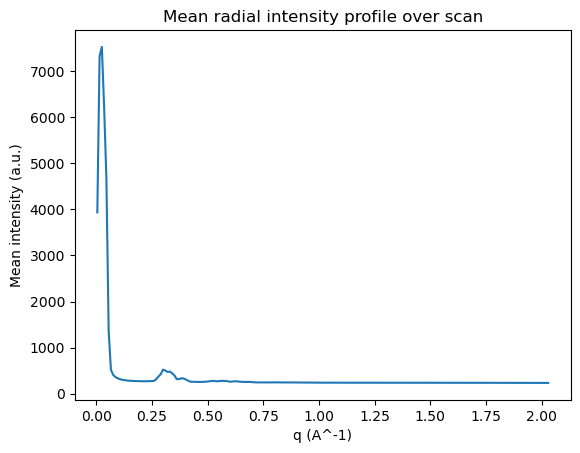

In [60]:
import numpy as np
import matplotlib.pyplot as plt

def _get_4d_data(obj):
    data = getattr(obj, "data", obj)
    if data.ndim != 4:
        raise ValueError(f"Expected 4D data, got shape {data.shape}")
    return data

def _get_k_calibration(obj, ky_len, kx_len, origin="center"):
    unit = "px"
    dky = dkx = 1.0

    if hasattr(obj, "axes_manager"):
        axes_all = list(obj.axes_manager.navigation_axes) + list(obj.axes_manager.signal_axes)
        ax_ky = next((ax for ax in axes_all if getattr(ax, "name", "") in ["k_y", "ky"]), None)
        ax_kx = next((ax for ax in axes_all if getattr(ax, "name", "") in ["k_x", "kx"]), None)
        if ax_ky is not None:
            dky = float(getattr(ax_ky, "scale", 1.0))
            unit = getattr(ax_ky, "units", unit) or unit
        if ax_kx is not None:
            dkx = float(getattr(ax_kx, "scale", 1.0))
            unit = getattr(ax_kx, "units", unit) or unit

    if origin == "center":
        ky = (np.arange(ky_len) - (ky_len - 1) / 2.0) * dky
        kx = (np.arange(kx_len) - (kx_len - 1) / 2.0) * dkx
    else:
        ky = np.arange(ky_len) * dky
        kx = np.arange(kx_len) * dkx

    return ky, kx, unit

def radial_profiles_4d(obj, nbins=200, r_max=None, origin="center", out_units="A^-1"):
    """
    Compute azimuthal (radial) intensity profile for every scan position.
    Returns:
      r_centers: (nbins,) radial coordinate
      prof: (scan_y, scan_x, nbins) binned mean intensity
      unit_out: str
    out_units:
      - "native": use axis units as-is (often 1/nm)
      - "A^-1": if native contains "1/nm", convert by *0.1
    """
    data = _get_4d_data(obj)
    sy, sx, ky_len, kx_len = data.shape

    ky, kx, unit = _get_k_calibration(obj, ky_len, kx_len, origin=origin)
    KX, KY = np.meshgrid(kx, ky)                  # (k_y, k_x)
    R = np.sqrt(KX**2 + KY**2)                    # (k_y, k_x)

    unit_out = unit
    R_use = R.copy()
    if out_units == "A^-1" and ("1/nm" in str(unit)):
        R_use = R_use * 0.1
        unit_out = "A^-1"
    elif out_units == "native":
        unit_out = unit

    if r_max is None:
        r_max = float(np.nanmax(R_use))

    dr = r_max / nbins
    bin_idx = np.floor(R_use / dr).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, nbins - 1)
    bin_idx_flat = bin_idx.ravel()

    counts = np.bincount(bin_idx_flat, minlength=nbins).astype(np.float64)
    counts[counts == 0] = np.nan  # avoid divide-by-zero

    prof = np.empty((sy, sx, nbins), dtype=np.float64)

    # loop over scan positions without materializing full 4D array
    for iy in range(sy):
        for ix in range(sx):
            dp = np.asarray(data[iy, ix, :, :], dtype=np.float64).ravel()
            sums = np.bincount(bin_idx_flat, weights=dp, minlength=nbins).astype(np.float64)
            prof[iy, ix, :] = sums / counts

    r_edges = np.linspace(0.0, r_max, nbins + 1)
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

    return r_centers, prof, unit_out

obj = s4d

r, prof, runit = radial_profiles_4d(obj, nbins=200, origin="center", out_units="A^-1")

mean_prof = np.nanmean(prof.reshape(-1, prof.shape[-1]), axis=0)

print("radial profile array shape:", prof.shape, " (expected scan_y, scan_x, nbins)")
print("r axis:", r.shape, "units:", runit, "  r_min/r_max:", float(r.min()), float(r.max()))

plt.figure()
plt.plot(r, mean_prof)
plt.xlabel(f"q ({runit})")
plt.ylabel("Mean intensity (a.u.)")
plt.title("Mean radial intensity profile over scan")
plt.show()

Beam energy used: 300.0 kV   electron λ = 0.01969 Å
r_mrad: (200,)   min/max: 0.1001024662552492 39.94088403584443


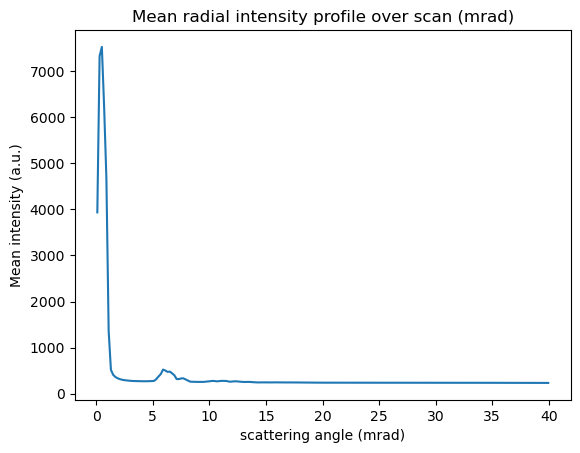

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def electron_wavelength_A(voltage_kV: float) -> float:
    """
    Relativistic electron wavelength in Å for an accelerating voltage in kV.
    """
    h = 6.62607015e-34       # J*s
    m = 9.1093837015e-31     # kg
    e = 1.602176634e-19      # C
    c = 299792458.0          # m/s

    V = float(voltage_kV) * 1e3  # volts
    lam_m = h / np.sqrt(2*m*e*V * (1.0 + (e*V)/(2*m*c**2)))
    return lam_m * 1e10          # Å

def _get_nested(md, path):
    cur = md
    for key in path.split("."):
        if cur is None:
            return None
        if hasattr(cur, key):
            cur = getattr(cur, key)
        elif isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return None
    return cur

def guess_beam_energy_kV(hs_signal, default_kV=200.0) -> float:
    md = getattr(hs_signal, "metadata", None)
    if md is None:
        return float(default_kV)

    candidates = [
        "Acquisition_instrument.TEM.beam_energy",
        "Acquisition_instrument.TEM.beam_energy_keV",
        "Acquisition_instrument.TEM.acceleration_voltage",
        "Acquisition_instrument.TEM.acceleration_voltage_kV",
        "Acquisition_instrument.SEM.beam_energy",
        "Acquisition_instrument.SEM.beam_energy_keV",
    ]
    for p in candidates:
        v = _get_nested(md, p)
        if v is None:
            continue
        try:
            v = float(v)
        except Exception:
            continue

        # Heuristic: if it's huge, treat as eV; otherwise keV
        if v > 1e3:
            return v / 1e3
        return v
    return float(default_kV)

def k_Ainv_to_mrad(k_Ainv, voltage_kV):
    lam_A = electron_wavelength_A(voltage_kV)
    return np.asarray(k_Ainv, dtype=float) * lam_A * 1e3  # mrad


voltage_kV = guess_beam_energy_kV(s4d, default_kV=200.0)
lam_A = electron_wavelength_A(voltage_kV)

r_Ainv = np.asarray(r, dtype=float)
if ("1/nm" in str(runit)) or (str(runit).strip() == "nm^-1"):
    r_Ainv = r_Ainv * 0.1

r_mrad = k_Ainv_to_mrad(r_Ainv, voltage_kV)

mean_prof = np.nanmean(prof.reshape(-1, prof.shape[-1]), axis=0)

print(f"Beam energy used: {voltage_kV:.1f} kV   electron λ = {lam_A:.5f} Å")
print("r_mrad:", r_mrad.shape, "  min/max:", float(np.nanmin(r_mrad)), float(np.nanmax(r_mrad)))

plt.figure()
plt.plot(r_mrad, mean_prof)
plt.xlabel("scattering angle (mrad)")
plt.ylabel("Mean intensity (a.u.)")
plt.title("Mean radial intensity profile over scan (mrad)")
plt.show()

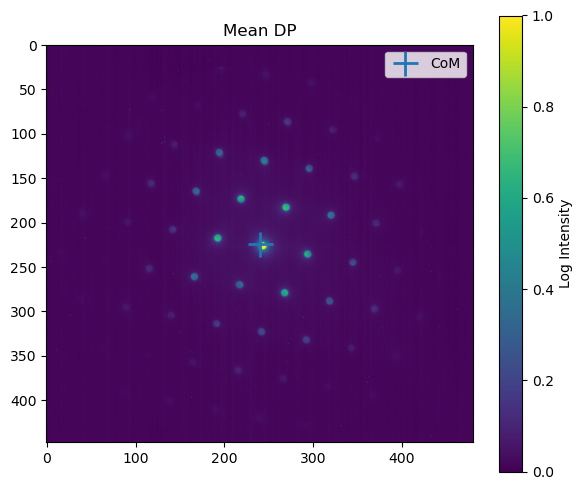

Global Center of Mass (pixels): y=223.63, x=239.72


In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Mean diffraction pattern over the scan (assumes s4d.data = (scan_y, scan_x, k_y, k_x))
dp_mean = np.asarray(s4d.data).mean(axis=(0, 1))  # (k_y, k_x)

# Global CoM in PIXEL coordinates
Iy, Ix = np.indices(dp_mean.shape)
I = dp_mean.astype(np.float64)
I_sum = I.sum()
com_y_pix = (Iy * I).sum() / I_sum
com_x_pix = (Ix * I).sum() / I_sum

# Plot (log-scaled, normalized for display)
eps = 1e-12
img = np.log1p(I + eps)
img = (img - img.min()) / (img.max() - img.min() + eps)

plt.figure(figsize=(6, 5))
plt.imshow(img, origin="upper", aspect="equal")
plt.plot(com_x_pix, com_y_pix, marker="+", markersize=18, markeredgewidth=2, linestyle="none", label="CoM")
plt.title("Mean DP")
plt.legend(loc="upper right")
cbar = plt.colorbar()
cbar.set_label("Log Intensity")
plt.tight_layout()
plt.show()

print(f"Global Center of Mass (pixels): y={com_y_pix:.2f}, x={com_x_pix:.2f}")

## Task 3: Virtual Detector Reconstruction

Generate a Virtual Bright Field (BF) image by integrating the central transmitted disk.

Generate an Annular Dark Field (ADF) image by integrating the scattered electrons in an outer ring.

Compare the Z-contrast in the ADF image to the diffraction contrast in the BF image.


In [63]:
from collections import OrderedDict

def _safe_getattr_chain(obj, chain, default=None):
    cur = obj
    for key in chain:
        if cur is None:
            return default
        # HyperSpy metadata often behaves like an object with attributes
        if hasattr(cur, key):
            cur = getattr(cur, key)
        elif isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return default
    return cur

def _get_pipeline_metadata(s4d):
    # sensible fallbacks
    meta = {
        "scan_step_size": (1.0, "px"),
        "detector_pixel_size": (1.0, "px"),
        "camera_length": (None, None),
    }

    if hasattr(s4d, "axes_manager"):
        axes_all = list(s4d.axes_manager.navigation_axes) + list(s4d.axes_manager.signal_axes)

        # scan step size from scan axes
        ax_sy = next((ax for ax in axes_all if getattr(ax, "name", "") == "scan_y"), None)
        ax_sx = next((ax for ax in axes_all if getattr(ax, "name", "") == "scan_x"), None)
        if ax_sy is not None and ax_sx is not None:
            # use mean of x/y step if both exist
            step = 0.5 * (float(getattr(ax_sy, "scale", 1.0)) + float(getattr(ax_sx, "scale", 1.0)))
            unit = getattr(ax_sx, "units", "px") or getattr(ax_sy, "units", "px") or "px"
            meta["scan_step_size"] = (step, unit)

        # detector reciprocal pixel size from k axes
        ax_ky = next((ax for ax in axes_all if getattr(ax, "name", "") == "k_y"), None)
        ax_kx = next((ax for ax in axes_all if getattr(ax, "name", "") == "k_x"), None)
        if ax_ky is not None and ax_kx is not None:
            dky = float(getattr(ax_ky, "scale", 1.0))
            dkx = float(getattr(ax_kx, "scale", 1.0))
            unit = getattr(ax_kx, "units", "px") or getattr(ax_ky, "units", "px") or "px"
            meta["detector_pixel_size"] = (0.5 * (dky + dkx), unit)

    # camera length: try common metadata paths (may be missing)
    if hasattr(s4d, "metadata"):
        md = s4d.metadata
        camlen = (
            _safe_getattr_chain(md, ["Acquisition_instrument", "TEM", "camera_length"])
            or _safe_getattr_chain(md, ["Acquisition_instrument", "TEM", "Camera_length"])
            or _safe_getattr_chain(md, ["Acquisition_instrument", "TEM", "camera length"])
        )
        if camlen is not None:
            meta["camera_length"] = (camlen, "m")  # unit may vary; keep simple

    return meta

def pipeline(s4d, detectors, compute_stats=True, compute_radial=False, nbins=200):
    """
    detectors: dict(name -> VirtualDetector)
    returns: {"meta":..., "images":{...}, "metrics":{...}}
    Requires these to already exist in your notebook from Tasks 1–2:
      - apply_virtual_detector(s4d, det)
      - total_intensity_map(obj)
      - com_maps(obj, ...)
      - radial_profiles_4d(obj, ...)
    """
    # progress bar (optional)
    try:
        from tqdm.auto import tqdm
    except Exception:
        tqdm = lambda x, **k: x

    meta = _get_pipeline_metadata(s4d)

    out = OrderedDict()
    out["meta"] = meta
    out["images"] = OrderedDict()
    out["metrics"] = OrderedDict()

    # apply detectors
    for name, det in tqdm(list(detectors.items()), desc="Applying virtual detectors"):
        out["images"][name] = apply_virtual_detector(s4d, det)

    # diffraction statistics
    if compute_stats:
        out["metrics"]["Itot"] = total_intensity_map(s4d)
        cy, cx, cu = com_maps(s4d, origin="center", out_units="native")
        out["metrics"]["CoM_y"] = cy
        out["metrics"]["CoM_x"] = cx
        out["metrics"]["CoM_unit"] = cu

    # optional (slower) radial profiles
    if compute_radial:
        r, prof, runit = radial_profiles_4d(s4d, nbins=nbins, origin="center", out_units="A^-1")
        out["metrics"]["r"] = r
        out["metrics"]["radial_profiles"] = prof
        out["metrics"]["r_unit"] = runit

    return out

Configuring detectors for diffraction shape (448, 480) at center (224, 240)
rmax=13.85 (k-axis units)
BF r_out=2.077 | ADF r_in=4.846, r_out=12.46


Applying virtual detectors:   0%|          | 0/2 [00:00<?, ?it/s]

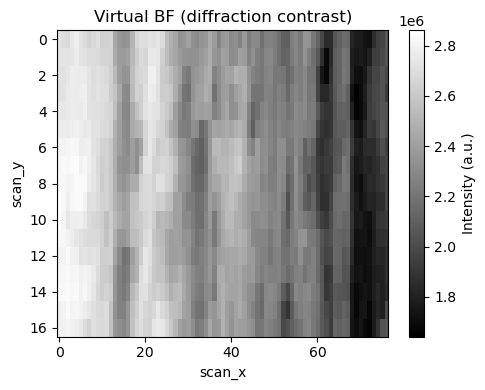

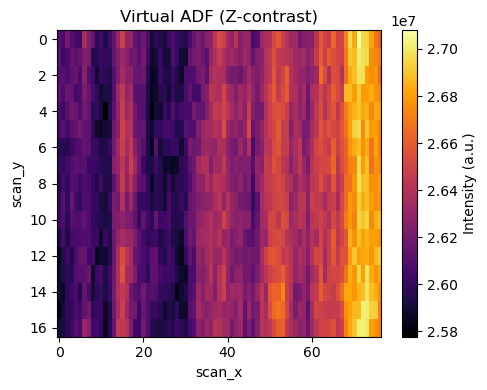


Observation on Contrast:
BF: contrast mainly from diffraction/strain/orientation affecting the transmitted disk.
ADF: high-angle scattering enhances mass-thickness / Z-contrast (heavier regions brighter).


In [64]:
import numpy as np
import matplotlib.pyplot as plt

def get_center_of_mass(dp, eps=1e-12):
    """dp: 2D diffraction pattern (k_y, k_x). Returns (cy, cx) in pixel units."""
    dp = np.asarray(dp, dtype=np.float64)
    yy, xx = np.indices(dp.shape)
    w = dp.sum() + eps
    cy = (dp * yy).sum() / w
    cx = (dp * xx).sum() / w
    return cy, cx

mean_dp = np.mean(s4d.data, axis=(0, 1))              # (k_y, k_x)
cy, cx = get_center_of_mass(mean_dp)
center_px = (int(round(float(cy))), int(round(float(cx))))

tmp = VirtualDetector(kind="BF", r_out=1.0, center_px=center_px)
rmax = tmp._fov_rmax(s4d, center_px[0], center_px[1])

bf_rout  = 0.15 * rmax
adf_rin  = 0.35 * rmax
adf_rout = 0.90 * rmax

bf  = VirtualDetector(kind="BF",  r_out=bf_rout,  center_px=center_px)
adf = VirtualDetector(kind="ADF", r_in=adf_rin, r_out=adf_rout, center_px=center_px)

detectors = {"BF": bf, "ADF": adf}

print(f"Configuring detectors for diffraction shape {mean_dp.shape} at center {center_px}")
print(f"rmax={rmax:.4g} (k-axis units)")
print(f"BF r_out={bf_rout:.4g} | ADF r_in={adf_rin:.4g}, r_out={adf_rout:.4g}")

# 3) Run pipeline
res = pipeline(s4d, detectors, compute_stats=True, compute_radial=False)

bf_img  = res["images"]["BF"]
adf_img = res["images"]["ADF"]

# 4) Plot
def show_virtual(img, title, cmap="gray", transpose=False):
    # works for either HyperSpy Signal2D or a plain numpy array
    arr = img.data if hasattr(img, "data") else np.asarray(img)
    if transpose:
        arr = arr.T  # use this if you want to match your friend's orientation

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(arr, cmap=cmap, origin="upper", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("scan_x")
    ax.set_ylabel("scan_y")
    fig.colorbar(im, ax=ax, label="Intensity (a.u.)")
    plt.tight_layout()
    plt.show()

show_virtual(bf_img,  "Virtual BF (diffraction contrast)", cmap="gray",    transpose=False)
show_virtual(adf_img, "Virtual ADF (Z-contrast)",          cmap="inferno", transpose=False)


print("\nObservation on Contrast:")
print("BF: contrast mainly from diffraction/strain/orientation affecting the transmitted disk.")
print("ADF: high-angle scattering enhances mass-thickness / Z-contrast (heavier regions brighter).")

## Task 4: Basic 4D-STEM Visualization

Launch the interactive 4D-STEM browser using `dataset.show()` (if using a local GUI) or `py4D.show_image()`.

Export a publication-quality figure of a virtual ADF image with a scale bar and a perceptually uniform colormap (e.g., `magma`).

In [65]:
import numpy as np

def _to_array(x):
    return x.data if hasattr(x, "data") else np.asarray(x)

def _unwrap_images_dict(res):
    # If pipeline returned (images, metrics) or similar
    if isinstance(res, (tuple, list)):
        for part in res:
            if isinstance(part, dict):
                res = part
                break

    if not isinstance(res, dict):
        raise TypeError(f"Pipeline returned {type(res)}, expected dict/tuple/list.")

    # If nested under common container keys
    for k in ["images", "virtual_images", "virtual", "outputs", "result", "results"]:
        if k in res and isinstance(res[k], dict):
            res = res[k]
            break

    return res

imgs = _unwrap_images_dict(results)
keys = list(imgs.keys())
print("Pipeline returned keys:", keys)

def _find_key(keys, token):
    token = token.lower()
    cands = [k for k in keys if isinstance(k, str) and token in k.lower()]
    return cands[0] if cands else None

bf_key  = _find_key(keys, "bf")
adf_key = _find_key(keys, "adf")

if bf_key is None or adf_key is None:
    if len(keys) == 2:
        bf_key, adf_key = keys[0], keys[1]
        print(f"Could not find explicit 'BF'/'ADF' keys; using first two keys: {bf_key}, {adf_key}")
    else:
        raise KeyError("Couldn't identify BF/ADF in returned keys above. Rename your detector dict keys to 'BF' and 'ADF'.")

bf_img  = _to_array(imgs[bf_key])
adf_img = _to_array(imgs[adf_key])

print("Using BF key:", bf_key, "| ADF key:", adf_key)
print("BF image shape:", bf_img.shape, "| ADF image shape:", adf_img.shape)

Pipeline returned keys: ['BF', 'ADF']
Using BF key: BF | ADF key: ADF
BF image shape: (17, 77) | ADF image shape: (17, 77)


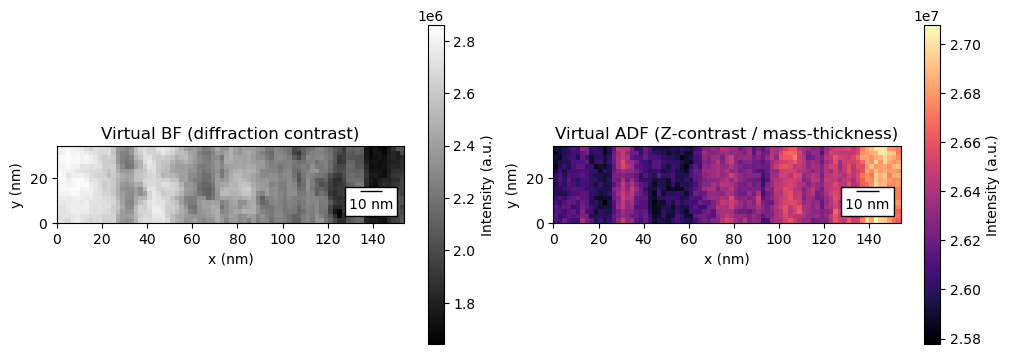

Saved: assignment_02_output/figures/task4_virtual_BF_ADF.png


In [66]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

def _find_axis(obj, target_name):
    if not hasattr(obj, "axes_manager"):
        return None
    for ax in list(obj.axes_manager.navigation_axes) + list(obj.axes_manager.signal_axes):
        if getattr(ax, "name", None) == target_name:
            return ax
    return None

def _to_nm(scale, units):
    """Convert a pixel scale to nm/pixel when possible; otherwise return scale unchanged and 'px'."""
    if units is None:
        return float(scale), "px"
    u = str(units).strip().lower()
    s = float(scale)

    if u in ["nm"]:
        return s, "nm"
    if u in ["um", "µm", "micron", "microns"]:
        return s * 1e3, "nm"
    if u in ["m"]:
        return s * 1e9, "nm"
    if u in ["pm"]:
        return s * 1e-3, "nm"
    if u in ["a", "å", "angstrom", "ångström", "ang"]:
        return s * 0.1, "nm"

    return s, units  # unknown; keep as-is

def add_scalebar(ax, px_size_nm, length_nm, label=None, loc="lower right"):
    if label is None:
        label = f"{length_nm:g} nm"
    bar = AnchoredSizeBar(
        ax.transData,
        size=length_nm,                   # data units (nm) because our axes use nm extents
        label=label,
        loc=loc,
        pad=0.3,
        borderpad=0.5,
        sep=5,
        frameon=True,
        fontproperties=fm.FontProperties(size=10),
    )
    ax.add_artist(bar)

ax_sy = _find_axis(s4d, "scan_y")
ax_sx = _find_axis(s4d, "scan_x")

dy, yunit = (float(getattr(ax_sy, "scale", 1.0)), getattr(ax_sy, "units", "px")) if ax_sy else (1.0, "px")
dx, xunit = (float(getattr(ax_sx, "scale", 1.0)), getattr(ax_sx, "units", "px")) if ax_sx else (1.0, "px")

dy_nm, yunit_nm = _to_nm(dy, yunit)
dx_nm, xunit_nm = _to_nm(dx, xunit)

sy, sx = bf_img.shape
x_extent_nm = (0.0, sx * dx_nm)
y_extent_nm = (0.0, sy * dy_nm)

bar_len = 0.25 * min(x_extent_nm[1] - x_extent_nm[0], y_extent_nm[1] - y_extent_nm[0])

nice = np.array([5, 10, 20, 50, 100, 200, 500, 1000], dtype=float)
bar_len = float(nice[np.argmin(np.abs(nice - bar_len))])

extent = [x_extent_nm[0], x_extent_nm[1], y_extent_nm[0], y_extent_nm[1]]

# --- plot + save ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im0 = axes[0].imshow(bf_img, origin="lower", extent=extent, cmap="gray")
axes[0].set_title("Virtual BF (diffraction contrast)")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Intensity (a.u.)")
add_scalebar(axes[0], dx_nm, bar_len, label=f"{bar_len:g} nm", loc="lower right")

im1 = axes[1].imshow(adf_img, origin="lower", extent=extent, cmap="magma")
axes[1].set_title("Virtual ADF (Z-contrast / mass-thickness)")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Intensity (a.u.)")
add_scalebar(axes[1], dx_nm, bar_len, label=f"{bar_len:g} nm", loc="lower right")

outdir = os.path.join("assignment_02_output", "figures")
os.makedirs(outdir, exist_ok=True)
outpath = os.path.join(outdir, "task4_virtual_BF_ADF.png")
fig.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

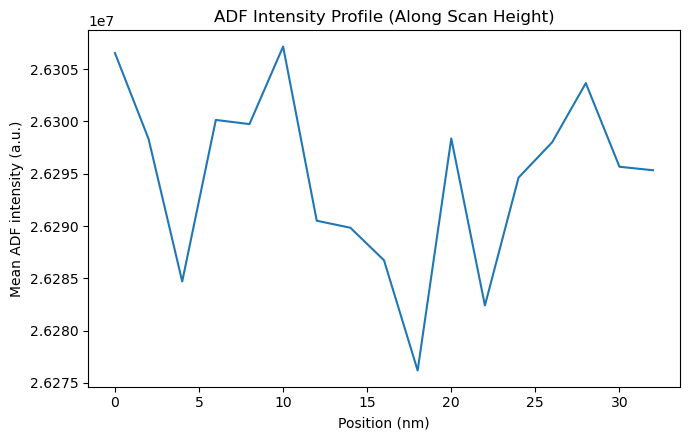

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# --- ADF line profile (mean intensity vs scan height in nm) ---

if "adf_img" in globals():
    adf_arr = np.asarray(adf_img)
    adf_sig = None
elif "results" in globals():
    # find the ADF key robustly (case-insensitive)
    adf_key = next((k for k in results.keys() if str(k).strip().lower() == "adf"), None)
    if adf_key is None:
        raise KeyError(f"Could not find an ADF entry in results. Available keys: {list(results.keys())}")
    adf_sig = results[adf_key]
    adf_arr = np.asarray(adf_sig.data if hasattr(adf_sig, "data") else adf_sig)
else:
    raise NameError("Need either `adf_img` or `results` in memory.")

# 2) Build a physical position axis (nm) using metadata if available, else fallback
step_nm = None
offset_nm = 0.0

if adf_sig is not None and hasattr(adf_sig, "axes_manager"):
    # By construction earlier: signal_axes[0]=scan_x, signal_axes[1]=scan_y
    ax_y = adf_sig.axes_manager.signal_axes[1]
    units = (str(getattr(ax_y, "units", "")) or "").lower()
    scale = float(getattr(ax_y, "scale", 1.0))
    offset = float(getattr(ax_y, "offset", 0.0))

    if units in ["nm", "nanometer", "nanometers"]:
        step_nm, offset_nm = scale, offset
    elif units in ["m", "meter", "meters"]:
        step_nm, offset_nm = scale * 1e9, offset * 1e9
    else:
        # unknown units -> assume scale is already in nm-ish
        step_nm, offset_nm = scale, offset
else:
    # fallback (use your known scan step size if you set one earlier)
    step_nm = float(globals().get("scan_step_nm", 2.0))
    offset_nm = 0.0

ny, nx = adf_arr.shape
pos_nm = offset_nm + np.arange(ny) * step_nm

# 3) Mean ADF intensity along scan height (average over scan_x)
profile = np.nanmean(adf_arr, axis=1)

plt.figure(figsize=(7, 4.5))
plt.plot(pos_nm, profile)
plt.xlabel("Position (nm)")
plt.ylabel("Mean ADF intensity (a.u.)")
plt.title("ADF Intensity Profile (Along Scan Height)")
plt.tight_layout()
plt.show()

ADF shape: (17, 77) | profiling along: columns (axis=1) | max position (nm): 152.0


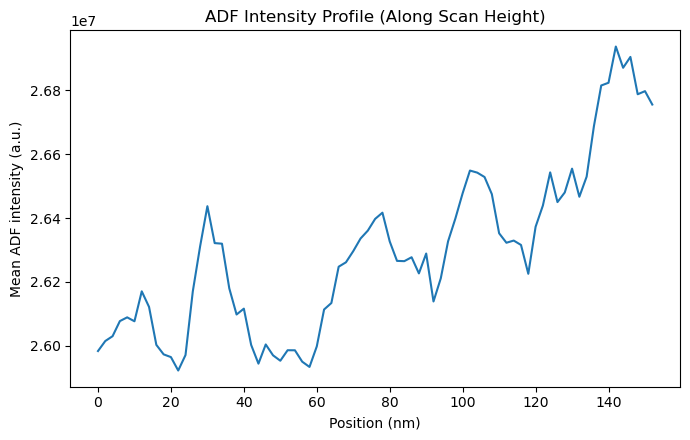

In [68]:
import numpy as np
import matplotlib.pyplot as plt

adf_arr = np.asarray(adf_img)  # shape like (17,77) or (77,17)

step_nm = 2.0

# choose the longer axis as the "scan height" direction
if adf_arr.shape[0] >= adf_arr.shape[1]:
    pos_nm = np.arange(adf_arr.shape[0]) * step_nm
    profile = np.nanmean(adf_arr, axis=1)   # average over x
    direction = "rows (axis=0)"
else:
    pos_nm = np.arange(adf_arr.shape[1]) * step_nm
    profile = np.nanmean(adf_arr, axis=0)   # average over y
    direction = "columns (axis=1)"

print("ADF shape:", adf_arr.shape, "| profiling along:", direction, "| max position (nm):", pos_nm[-1])

plt.figure(figsize=(7,4.5))
plt.plot(pos_nm, profile)
plt.xlabel("Position (nm)")
plt.ylabel("Mean ADF intensity (a.u.)")
plt.title("ADF Intensity Profile (Along Scan Height)")
plt.tight_layout()
plt.show()

## Task 5: Finalize and Submit

Update your `README.md` with a brief explanation of how virtual detectors allow post-acquisition imaging.

Push the completed Week 02 notebook to your GitHub repository.

Submit the repository link on Canvas.


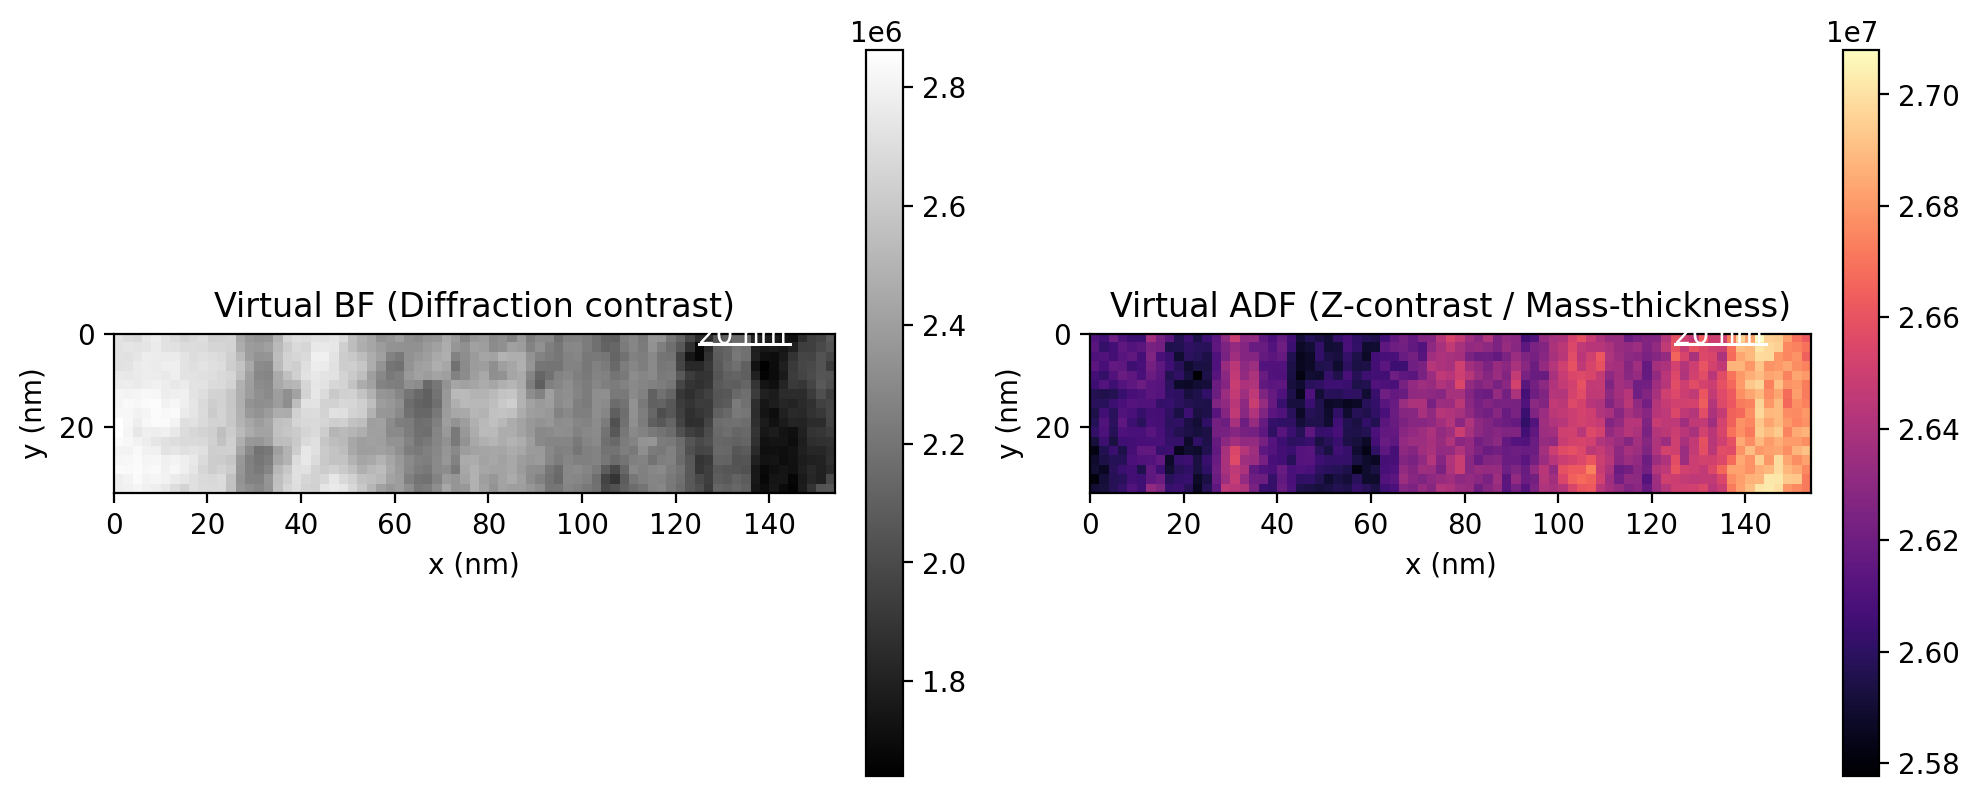

Saved: assignment_02_output/figures/virtual_BF_ADF.png
Saved: assignment_02_output/figures/virtual_BF_ADF.pdf


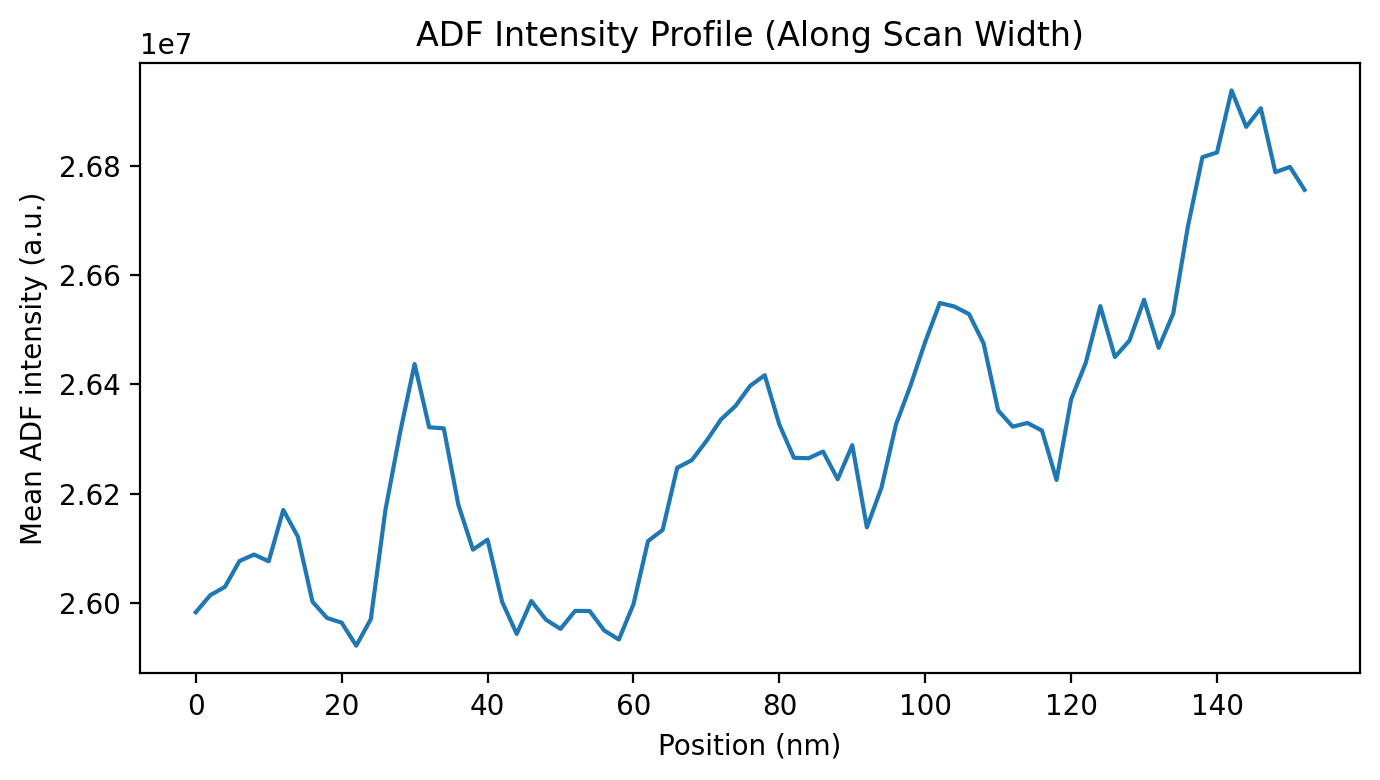

Saved: assignment_02_output/figures/adf_line_profile.png
Saved: assignment_02_output/figures/adf_line_profile.pdf


In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- helpers ----------
def _to_array(x):
    return x.data if hasattr(x, "data") else np.asarray(x)

def _unit_to_nm_factor(unit):
    u = (unit or "").strip().lower()
    if u in ["nm", "nanometer", "nanometers"]:
        return 1.0
    if u in ["um", "µm", "micron", "microns"]:
        return 1e3
    if u in ["m", "meter", "meters"]:
        return 1e9
    # unknown -> assume already nm
    return 1.0

def get_scan_step_nm(s4d, fallback_nm=2.0):
    if hasattr(s4d, "axes_manager"):
        axes_all = list(s4d.axes_manager.navigation_axes) + list(s4d.axes_manager.signal_axes)
        ax = next((a for a in axes_all if getattr(a, "name", "") in ["scan_x", "scan_y"]), None)
        if ax is not None:
            scale = float(getattr(ax, "scale", fallback_nm))
            units = getattr(ax, "units", "nm")
            return scale * _unit_to_nm_factor(units)
    return float(fallback_nm)

def add_scalebar(ax, length_nm, px_size_nm, loc="lower right", pad_frac=0.06, height_frac=0.02):
    """
    Draw a simple scale bar in data coordinates (nm).
    Assumes imshow extent is in nm so x/y are nm.
    """
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    w = abs(x1 - x0)
    h = abs(y1 - y0)

    bar_len = float(length_nm)
    bar_h   = height_frac * h
    pad_x   = pad_frac * w
    pad_y   = pad_frac * h

    if loc == "lower right":
        bx = max(x0, x1) - pad_x - bar_len
        by = min(y0, y1) + pad_y
        text_y = by + bar_h + 0.02 * h
        ha = "left"
    else:  # lower left
        bx = min(x0, x1) + pad_x
        by = min(y0, y1) + pad_y
        text_y = by + bar_h + 0.02 * h
        ha = "left"

    rect = Rectangle((bx, by), bar_len, bar_h, facecolor="white", edgecolor="none", zorder=5)
    ax.add_patch(rect)
    ax.text(bx, text_y, f"{bar_len:g} nm", color="white", fontsize=10, ha=ha, va="bottom", zorder=6)

# ---------- inputs ----------
bf = _to_array(bf_img)
adf = _to_array(adf_img)

scan_step_nm = get_scan_step_nm(s4d, fallback_nm=2.0)

ny, nx = adf.shape
extent_nm = [0, nx * scan_step_nm, ny * scan_step_nm, 0]  # [xmin,xmax,ymin,ymax] with origin="upper"

# ---------- output directory ----------
base_dir = "assignment_02_output"
fig_dir = os.path.join(base_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# ---------- (1) BF + ADF figure ----------
fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=200)

im0 = axes[0].imshow(bf, cmap="gray", origin="upper", extent=extent_nm, aspect="equal")
axes[0].set_title("Virtual BF (Diffraction contrast)")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
add_scalebar(axes[0], length_nm=20, px_size_nm=scan_step_nm, loc="lower right")

im1 = axes[1].imshow(adf, cmap="magma", origin="upper", extent=extent_nm, aspect="equal")
axes[1].set_title("Virtual ADF (Z-contrast / Mass-thickness)")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
add_scalebar(axes[1], length_nm=20, px_size_nm=scan_step_nm, loc="lower right")

plt.tight_layout()
out_png = os.path.join(fig_dir, "virtual_BF_ADF.png")
out_pdf = os.path.join(fig_dir, "virtual_BF_ADF.pdf")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)

# ---------- (2) Analysis plot: mean ADF intensity vs position across x (scan_x) ----------
x_nm = np.arange(nx) * scan_step_nm
adf_line = np.mean(adf, axis=0)  # average along scan_y -> profile across scan_x

plt.figure(figsize=(7, 4), dpi=200)
plt.plot(x_nm, adf_line)
plt.xlabel("Position (nm)")
plt.ylabel("Mean ADF intensity (a.u.)")
plt.title("ADF Intensity Profile (Along Scan Width)")
plt.tight_layout()

out_png = os.path.join(fig_dir, "adf_line_profile.png")
out_pdf = os.path.join(fig_dir, "adf_line_profile.pdf")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)